# AI Recommendation System Using MovieLens 100k

This notebook follows the project brief for building an AI-based recommendation system using collaborative filtering.

## Objectives
- Understanding Recommendation Systems
- Explore and preprocess the MovieLens 100k dataset
- Data splitting the dataset for model
- Train a Singular Value Decomposition(SVD) recommendation model
- Evaluate model performance using RMSE
- Hyperparameter Tuning
- Generate top-N movie recommendations
- Reflect on ethical issues in recommender systems

# Understanding Recommendation Systems

## Collaborative filtering

Collaborative filtering uses user interaction data (e.g., user ratings) to recommend items. It finds patterns in users' behavior and uses those patterns to predict what a user will like.

- **User-based vs Item-based:**
  - *User-based:* Recommend items to a user based on similar users' preferences — if users A and B rated many items similarly, items liked by B but unseen by A can be recommended to A.
  - *Item-based:* Recommend items similar to those a user has liked before — similarity is computed between items using user ratings (items frequently co-rated by users are considered similar).

## Collaborative vs Content-based filtering

- **Collaborative filtering:** Learns from the collective behavior of users. It assumes that if users agreed in the past, they will agree in the future and uses those agreement patterns to make predictions.
- **Content-based filtering:** Uses item attributes (e.g., genre, tags, metadata) and a user's profile of liked item features to recommend similar items. This method requires descriptive item features but works well for new users if their preferences are known via content signals.

# Data exploration and preprocessing

This project uses the MovieLens 100k dataset, which contains user ratings for movies. The data includes user IDs, movie IDs, ratings, and timestamps, and it is suitable for collaborative filtering recommender systems.

In [1]:
!pip install surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 31.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 27.4 MB/s  0:00:00m0:00:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 34.7 MB/s  0:00:016m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [surprise]4/6 [scikit-surprise]


In [2]:
from surprise import Dataset, SVD, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

# Load data and split
data = Dataset.load_builtin("ml-100k",prompt=False)

Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /home/codespace/.surprise_data/ml-100k


In [4]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 16.3 MB/s  0:00:00m0:00:010:01


In [7]:
!pip install matplotlib

In [6]:
pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 31.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 30.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 22.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Load the MovieLens data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Convert the Surprise Dataset to a pandas DataFrame
ratings = pd.DataFrame(data.raw_ratings, columns=['user_id', 'item_id', 'rating', 'timestamp'])

# Display the first few rows
print(ratings.head())


  user_id item_id  rating  timestamp
0     196     242     3.0  881250949
1     186     302     3.0  891717742
2      22     377     1.0  878887116
3     244      51     2.0  880606923
4     166     346     1.0  886397596


In [10]:
# Display the number of ratings, unique users, unique movies, and the range of ratings
print('Number of Ratings:', len(ratings))
print('Number of unique users:', ratings['user_id'].nunique())
print('Number of unique movies:', ratings['item_id'].nunique())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())

# Display the first few rows of the ratings DataFrame
print(ratings.head())

Number of Ratings: 100000
Number of unique users: 943
Number of unique movies: 1682
Rating range: 1.0 to 5.0
  user_id item_id  rating  timestamp
0     196     242     3.0  881250949
1     186     302     3.0  891717742
2      22     377     1.0  878887116
3     244      51     2.0  880606923
4     166     346     1.0  886397596


In [11]:
# Display the structure and summary of the ratings DataFrame
print(ratings.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    100000 non-null  str    
 1   item_id    100000 non-null  str    
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.1 MB
None


There is no NaN Values. Hence no null data cleaning needed. Rating is also of int64 type. Covert it to Float.

In [12]:
# Convert rating column to float type
ratings['rating'] = ratings['rating'].astype(float)

In [13]:
# check for duplicate rows based on user_id and item_id
duplicate_rows = ratings.duplicated(subset=['user_id', 'item_id'])

In [14]:
print('Number of duplicate rows based on user_id and item_id:', duplicate_rows.sum())

Number of duplicate rows based on user_id and item_id: 0


In [15]:
# Display the summary statistics of the ratings DataFrame
print(ratings.describe())

              rating
count  100000.000000
mean        3.529860
std         1.125674
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000


#### Visualize data to gain insights into the distribution of ratings, number of ratings per user, etc.

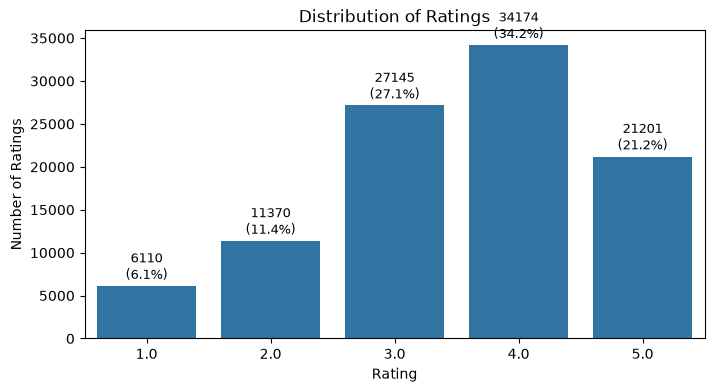

In [16]:
# Display the distribution of ratings using a bar plot
rating_counts = ratings.groupby('rating').size()

total = rating_counts.sum()
percentages = (rating_counts / total) * 100

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=rating_counts.index, y=rating_counts.values)

for i, (count, pct) in enumerate(zip(rating_counts.values, percentages.values)):
    ax.text(
        i,
        count + max(rating_counts.values) * 0.01,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

83.5% of the rating is 3 and above. Only 6% of the users rated a movie 1.

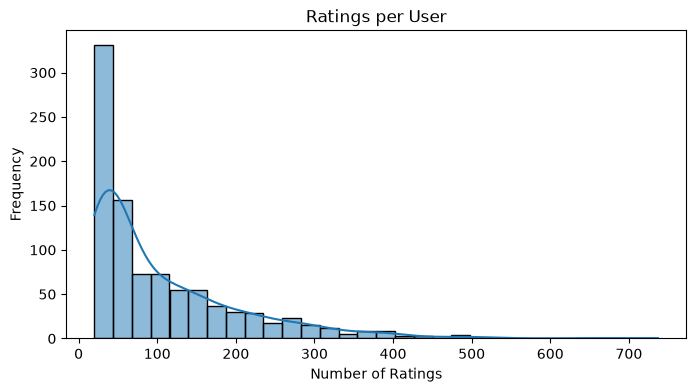

In [17]:
# Display the distribution of ratings per user using a histogram
user_counts = ratings.groupby('user_id').size()
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=30, kde=True)
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

Most of the users rated less than 100 movies.

# Data Splitting

Split the dataset into training and testing sets. The training set will be used to train the recommendation model, and the testing set will help evaluate its performance.

In [18]:
ratings_final = ratings.rename(columns={"rating": "raw_ratings"})
print(ratings_final)

      user_id item_id  raw_ratings  timestamp
0         196     242          3.0  881250949
1         186     302          3.0  891717742
2          22     377          1.0  878887116
3         244      51          2.0  880606923
4         166     346          1.0  886397596
...       ...     ...          ...        ...
99995     880     476          3.0  880175444
99996     716     204          5.0  879795543
99997     276    1090          1.0  874795795
99998      13     225          2.0  882399156
99999      12     203          3.0  879959583

[100000 rows x 4 columns]


In [19]:
# Split Data for training and testing
trainset, testset = train_test_split(data, test_size=0.25)
allData, noData = train_test_split(data, test_size=1)


# Model Selection

SVD (Singular Value Decomposition) is a popular algorithm for collaborative filtering.

In [20]:
# Using the Surprise library, for model implementations SVD algorithms.
from surprise import SVD

model = SVD()
model.fit(trainset)

# Model Evaluation

In [21]:
from surprise.model_selection import cross_validate

# Run 5-fold cross-validation and print results.
cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9289  0.9323  0.9444  0.9476  0.9266  0.9360  0.0084  
MAE (testset)     0.7302  0.7375  0.7451  0.7465  0.7304  0.7379  0.0070  
Fit time          0.84    1.02    0.63    0.63    1.02    0.83    0.17    
Test time         0.16    0.16    0.11    0.08    0.16    0.13    0.03    


{'test_rmse': array([0.92894946, 0.93234947, 0.94444393, 0.94759611, 0.92661731]),
 'test_mae': array([0.73021932, 0.73750003, 0.74510395, 0.74653357, 0.73036689]),
 'fit_time': (0.8367042541503906,
  1.0172481536865234,
  0.6296005249023438,
  0.6312961578369141,
  1.0234017372131348),
 'test_time': (0.15631914138793945,
  0.16419291496276855,
  0.11055636405944824,
  0.07614564895629883,
  0.15883183479309082)}

In [22]:
# Make Predictions
predictions = model.test(testset)

In [23]:
# After making predictions, calculate RMSE
from surprise import accuracy

rmse = accuracy.rmse(predictions)
print(f"Root Mean Squared Error: {rmse}")

RMSE: 0.7315
Root Mean Squared Error: 0.7314618075080979


#  Hyperparameter Tuning

Hyperparameters such as n_factors (number of latent factors), n_epochs (number of iterations), and lr_all (learning rate) can be tuned to improve model performance.

In [ ]:
from surprise.model_selection import GridSearchCV

param_grid = {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
grid_search.fit(data)
print(grid_search.best_params)

# Top N Recommendations

The model is trained, hence generate the top N recommendations for each user.
Sort predicted ratings and recommend the highest-rated items for each user.

In [ ]:
def get_top_n(predictions, n):

   top_n = {}
   for uid, iid, true_r, est, _ in predictions:
       if uid not in top_n:
           top_n[uid] = []
       top_n[uid].append((iid, est))


   for uid, user_ratings in top_n.items():
       user_ratings.sort(key=lambda x: x[1], reverse=True)
       top_n[uid] = user_ratings[:n]

   return top_n

recommendations = get_top_n(predictions, n=10)

for uid, user_ratings in recommendations.items():
   print(uid, [iid for (iid, _) in user_ratings])

891 ['459', '107', '742', '274', '117', '281', '595']
326 ['434', '519', '183', '732', '479', '657', '318', '79', '64', '615']
660 ['181', '483', '208', '603', '318', '83', '357', '172', '135', '96']
311 ['22', '96', '172', '64', '98', '511', '651', '479', '136', '82']
398 ['427', '194', '96', '197', '482', '493', '520', '87', '1', '519']
35 ['300', '332', '242', '327', '748', '266', '261', '877']
96 ['64', '127', '483', '318', '187', '100', '173', '195', '478', '645']
291 ['69', '50', '168', '496', '98', '234', '195', '48', '100', '7']
519 ['1062', '333', '327', '336', '1617', '349', '266', '288', '339', '264']
290 ['143', '64', '28', '132', '172', '265', '527', '216', '498', '133']
886 ['64', '174', '98', '191', '79', '176', '216', '1', '7', '483']
450 ['318', '194', '496', '478', '199', '921', '22', '936', '143', '316']
198 ['174', '923', '183', '172', '357', '56', '153', '81', '527', '204']
121 ['124', '98', '197', '509', '257', '181', '514', '508', '1266', '742']
158 ['173', '408'

# Ethical considerations
This project highlights the importance of fairness, privacy, and transparency in recommender systems. Bias in training data can lead to unfair recommendations, while privacy must be respected when handling user activity. The system should also be transparent about how recommendations are generated.

In summary, this notebook demonstrates how to build, evaluate, and improve a collaborative filtering recommendation system using the MovieLens 100k dataset.